## objective
1) Understand and define the AgentState structure;    
2) create simple node function to process and update state   
3) Set up a basic LangGraph structure   
4) Compile and invoke a LangGraph graph   
5) Understand how data flows through a single-node in LangGraph

1) 理解并定义agentstate 结构
2) 创建简单的节点函数来处理和更新状态
3) 设置基本的LangGraph 结构
4) 编译和调用LangGraph 图；
5) 理解数据如何在LangGraph 的单个节点流动；

### Hello World Agent 

Our first LangGraph graph!  
this section we will learn three main things-dict,type dict and state graph

### bulid class agent state (构建类代理状态)

In [ ]:

from typing import Dict, TypedDict
from langgraph.graph import StateGraph


class AgentState(TypedDict): # our state scheme
    message : str

# 第一部分节点函数的定义与Python语法细节
def greeting_node(state: AgentState) -> AgentState:
#底层逻辑是：Python类型提示；state: AgentState 规定了传入这个函数的参数是 state（而且是AgentState这个类型也就是我们定义的类型字典typedict ）
# -> AgentState: 规定了这个函数执行完毕后，return 返回的数据也必须是这个AgentState 这个类型！！
#为什么？在常规的简单 Python 脚本里不写也没关系。但在 LangGraph 这样严谨的工程框架中，它是强制性的质检标准。LangGraph 底层会读取这个 -> 符号后面的类型，如果你在函数里不小心 return 了一个列表或者一个数字，系统在图运行之前就会直接报错，防止错误的数据流进下一个节点。
    """Simple node that adds a greeting message to the state"""
# 在基础Python 中，叫作文档字符串 Docstring 是写给程序员看的注释；但是在AI/Agent 框架中，当你把一个函数封装成“工具（Tool）”交给大模型（比如 GPT-4）去调用时，大模型是看不懂你里面写的代码逻辑的，它就是靠读取这段 """...""" 里的纯文本，来判断自己该不该用这个工具、这个工具是干嘛的。
    state['message'] = "hey " + state['message'] + ", how is your day going?" #对字典内部的值进行跟新覆盖；

    return state
# 这部分就是状态的更新与返回；

# 第二部分：StateGraph 的底层编译与执行逻辑

graph = StateGraph(AgentState)
#底层逻辑：StateGraph 在底层维护一个 有向图 的数据结构（包含节点与边）
graph.add_node("greeter",greeting_node)

graph.set_entry_point("greeter")   #是在图的数据结构中，硬编码一条特殊的边：START ->
graph.set_finish_point("greeter")  #同样是增加一条特殊的边："greeter" -> END。告诉系统，这个节点执行完，不要再往下找了，立刻终止循环并抛出最终数据。

app = graph.compile()
#为什么需要进行Compile 编译？你前面的 add_node 和 set_entry_point，本质上只是在画设计图纸，往一个列表里塞配置信息。这些配置信息是散装的，不能直接运行。
#compile() 在干什么？ 当你调用 compile() 时，LangGraph 底层会执行一套复杂的校验算法：检查所有的节点是不是都有入口和出口？有没有死循环（除非你故意设计）？检查所有连线（Edges）是否合法？
#核心转化： 校验通过后，它会把你这张“图纸”实例化为一个 CompiledGraph 对象（也就是代码里的 app）。这个 app 对象拥有了实际分配内存、管理状态流转、并且可以被调用的能力（比如 invoke）。

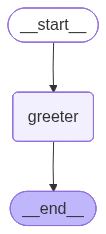

In [3]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
#第三部分：运行与数据提取
result = app.invoke({"message":"Bob"})  
#invoke 的逻辑：触发这个图运行的启动命令，
result["message"]
#这是 Python 字典提取数值的标准语法。因为 result 是个字典，里面可能未来还会存入 {"message": "...", "data": [...], "score": 95} 等等很多键值对。result["message"] 的意思就是：我只想要这个字典里，键名为 message 所对应的那段具体文字内容。 所以最终在屏幕上，你只能看到那句打招呼的纯文本，而看不到字典的 {} 括号。

'hey Bob, how is your day going?'

### 后续的深入：
怎么定义 State： 学会怎么往 TypedDict 里加更多的字段（比如加上你需要的温度、转化率列表）。   

怎么把普通函数变成 Node： 像截图中那样，学会让函数接收 state 并返回 state。   

怎么画条件边 (Conditional Edges)： 这是视频里一定会讲的。也就是怎么写 if/else 来决定箭头的走向。比如：“如果预测活性 > 90%，走向 [结束] 节点；如果 < 90%，指向 [贝叶斯优化] 节点”。   

In [5]:
class CatalystState(TypedDict):
    temperature: float       # 碳化温度
    precursor: str           # 前驱体类型
    literature_context: str  # 查到的文献总结
    predicted_activity: float # SVR预测出的活性

In [6]:
def svr_prediction_node(state: CatalystState) -> CatalystState:
    # 从化验单上读取温度
    temp = state['temperature'] 
    # 跑你的机器学习模型
    result = my_svr_model.predict(temp) 
    # 把预测结果写回化验单
    state['predicted_activity'] = result 
    return state

In [7]:
graph.add_node("文献检索", search_node)
graph.add_node("SVR预测", svr_prediction_node)
# 规定先查文献，查完再预测 (这就是串行依赖！)
graph.add_edge("文献检索", "SVR预测")

NameError: name 'search_node' is not defined